In [2]:
import opt_einsum as oe
import numpy as np
import torch
import sys
sys.path.append("../../")
import mps
from mps.trainer.data_utils import SyntheticDataset, SyntheticDatasetV2, SyntheticDatasetV3

import mps

In [3]:
N = 40
batch_size = 100

x0 = torch.randint(0, 2, (batch_size, N)).to(torch.float64)
x0[:, 0] = 1

x1 = x0.clone()
x1[:, 0] = 0

psi0 = torch.stack([x0, 1 - x0], dim=-1)
psi1 = torch.stack([x1, 1 - x1], dim=-1)

psi = torch.concat([psi0, psi1], dim=0)


In [15]:
from mps import tpcp_mps
import random

def get_metrics(N, runs, dtype, grad_i = 0):
    batch_size = 100
    x0 = torch.randint(0, 2, (batch_size, N)).to(torch.float64)
    x0[:, 0] = 1
    x1 = x0.clone()
    x1[:, 0] = 0
    psi0 = torch.stack([x0, 1 - x0], dim=-1)
    psi1 = torch.stack([x1, 1 - x1], dim=-1)
    psi = torch.concat([psi0, psi1], dim=0)


    delta_rho_list = []
    grad_list = []
    for run in range(runs):
        seed = run + N*100
        torch.manual_seed(seed)  
        np.random.seed(seed)
        random.seed(seed)
        tpcp = tpcp_mps.MPSTPCP(
            N,
            K=1,
            d=2,
            enable_r=True,
            with_identity=False,
            manifold=tpcp_mps.ManifoldType.EXACT,
            dtype=dtype,
        )
        tpcp.train()

        out, reg = tpcp(psi.to(dtype),return_reg=True)
        tpcp.W.requires_grad = False
        tpcp.r.requires_grad = False
        delta_rho = tpcp.rho_last
        delta_rho = delta_rho[:batch_size] - delta_rho[batch_size:]

        delta_rho_list.append(delta_rho)

        loss = torch.abs(delta_rho).mean()
        loss.backward()
        g = tpcp.kraus_ops.kraus_ops[grad_i].grad
        grad_list.append(g)
    
    # print(delta_rho_list[0].shape)
    # calculate the mean and variance of each element of delta_rho_list
    delta_rho_list = torch.stack(delta_rho_list, dim=0)
    mean_delta_rho = torch.mean(delta_rho_list, dim=0)
    var_delta_rho = torch.var(delta_rho_list, dim=0)

    grad_list = torch.stack(grad_list, dim=0)
    mean_grad = torch.mean(grad_list, dim=0)
    var_grad = torch.var(grad_list, dim=0)

    return mean_delta_rho, var_delta_rho, mean_grad, var_grad

In [16]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt
# Define parameters for the simulation
runs = 1000  # you can reduce this number for quicker tests
dtype = torch.complex128

# Lists to store N values and the corresponding mean variance
N_values = list(range(5, 13))
mean_variances = []
mean_grad_variances = []


for N in N_values:
    mean_delta_rho, var_delta_rho, mean_grad, var_grad = get_metrics(N, runs, dtype, -1)
    # Take the mean of the variance (averaging over all elements in delta_rho)
    mean_var = var_delta_rho.mean().item()
    mean_variances.append(mean_var)
    mean_grad_var = var_grad.mean().item()
    mean_grad_variances.append(mean_grad_var)
    print(f"N = {N}, Mean Variance = {mean_var}")


N = 5, Mean Variance = 0.012854177715636336
N = 6, Mean Variance = 0.005094865565461051
N = 7, Mean Variance = 0.0020618054398250287
N = 8, Mean Variance = 0.0008364133822361328
N = 9, Mean Variance = 0.00031415243204158783
N = 10, Mean Variance = 0.00012458600229992467
N = 11, Mean Variance = 5.2627019994381574e-05
N = 12, Mean Variance = 2.0796472296316093e-05


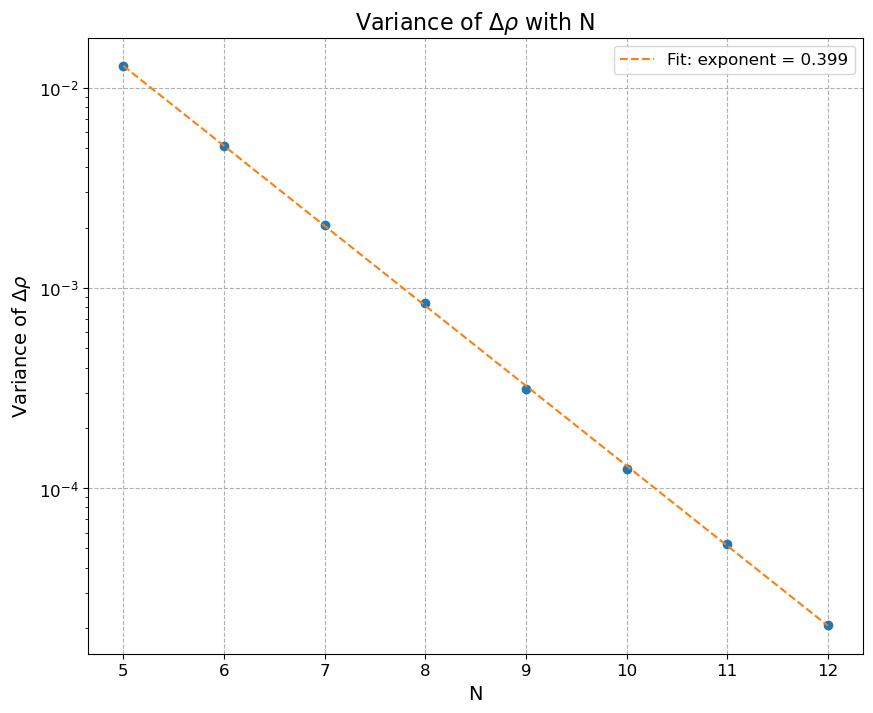

In [17]:
# Convert lists to numpy arrays for the fit
N_array = np.array(N_values)
mean_variances_array = np.array(mean_variances)

# Perform a linear regression on the logarithm of the mean variance
log_mean_variances = np.log(mean_variances_array)
coeffs = np.polyfit(N_array, log_mean_variances, 1)
slope, intercept = coeffs
fit_line = np.exp(intercept + slope * N_array)

# Plot the data and the fit with exponent in the legend
plt.figure(figsize=(10, 8))  # Increase the figure size
plt.plot(N_values, mean_variances, marker='o', linestyle='')
plt.plot(N_values, fit_line, linestyle='--', label=f'Fit: exponent = {np.exp(slope):.3f}')
plt.xlabel('N', fontsize=14)  # Increase font size
plt.ylabel('Variance of $\Delta \\rho$', fontsize=14)  # Increase font size
plt.yscale('log')
plt.title('Variance of $\Delta \\rho$ with N', fontsize=16)  # Increase font size
plt.grid(True, ls="--")  # Change grid to only show major ticks
plt.tick_params(axis='both', which='major', labelsize=12)  # Increase tick size
plt.legend(fontsize=12)  # Increase legend size
plt.show()

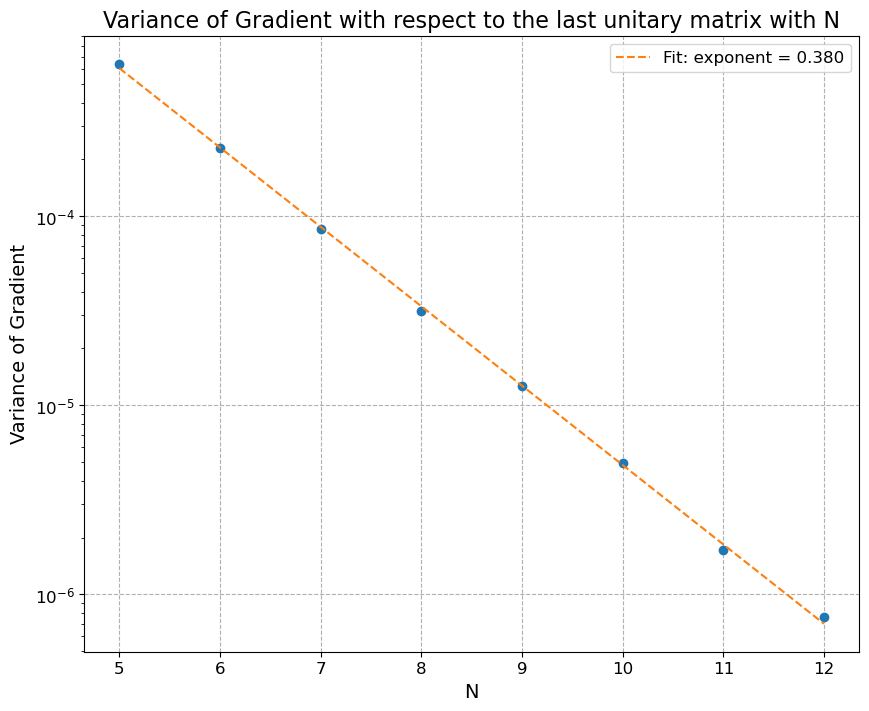

In [18]:
# Convert lists to numpy arrays for the fit
N_array = np.array(N_values)
mean_grad_variances_array = np.array(mean_grad_variances)

# Perform a linear regression on the logarithm of the mean gradient variance
log_mean_grad_variances = np.log(mean_grad_variances_array)
coeffs = np.polyfit(N_array, log_mean_grad_variances, 1)
slope, intercept = coeffs
fit_line = np.exp(intercept + slope * N_array)

# Plot the data and the fit with exponent in the legend
plt.figure(figsize=(10, 8))  # Increase the figure size
plt.plot(N_values, mean_grad_variances, marker='o', linestyle='')
plt.plot(N_values, fit_line, linestyle='--', label=f'Fit: exponent = {np.exp(slope):.3f}')
plt.xlabel('N', fontsize=14)  # Increase font size
plt.ylabel('Variance of Gradient', fontsize=14)  # Increase font size
plt.yscale('log')
plt.title('Variance of Gradient with respect to the last unitary matrix with N', fontsize=16)  # Increase font size
plt.grid(True, ls="--")  # Change grid to only show major ticks
plt.tick_params(axis='both', which='major', labelsize=12)  # Increase tick size
plt.legend(fontsize=12)  # Increase legend size
plt.show()

# Barren Plateau with NLL


In [67]:
N = 20
batch_size = 100
x0 = torch.randint(0, 2, (batch_size, N)).to(torch.float64)
x0[:, 0] = 1
x1 = x0.clone()
x1[:, 0] = 0
psi0 = torch.stack([x0, 1 - x0], dim=-1)
psi1 = torch.stack([x1, 1 - x1], dim=-1)
psi = torch.concat([psi0, psi1], dim=0)

In [68]:
from mps.trainer.utils import focal_loss
import geoopt


def grad_NLL(tpcp, N, batch_size, dtype):
    N = 20
    batch_size = 100
    x0 = torch.randint(0, 2, (batch_size, N)).to(torch.float64)
    x0[:, 0] = 1
    x1 = x0.clone()
    x1[:, 0] = 0
    psi0 = torch.stack([x0, 1 - x0], dim=-1)
    psi1 = torch.stack([x1, 1 - x1], dim=-1)
    psi = torch.concat([psi0, psi1], dim=0)


    tpcp = tpcp_mps.MPSTPCP(
        N,
        K=1,
        d=2,
        enable_r=True,
        with_identity=False,
        manifold=tpcp_mps.ManifoldType.EXACT,
        dtype=dtype,
    )
    tpcp.train()

    lr = 0.1
    optimizer = geoopt.optim.RiemannianSGD(tpcp.kraus_ops.parameters(), lr=lr)
    
    grad_first = []
    grad_last = []
    loss_list = []
    for _ in range(500):

        optimizer.zero_grad()
        out, reg = tpcp(psi.to(dtype),return_reg=True, return_probs=True)
        loss = focal_loss(out, psi[:, 0, 0])
        loss.backward()
        loss_list.append(loss.item())
        grad_first.append(torch.norm(tpcp.kraus_ops.kraus_ops[0].grad))
        grad_last.append(torch.norm(tpcp.kraus_ops.kraus_ops[-1].grad))
        optimizer.step()


        print(torch.norm(tpcp.kraus_ops.kraus_ops[-1].grad))
        print(out)
        print(loss)

MPSTPCP(
  (kraus_ops): kraus_operators(
    (manifold): Stiefel(euclidean)(exact) manifold
    (kraus_ops): ParameterList(
        (0): Parameter containing: [torch.complex128 of size 4x4]
        (1): Parameter containing: [torch.complex128 of size 4x4]
        (2): Parameter containing: [torch.complex128 of size 4x4]
        (3): Parameter containing: [torch.complex128 of size 4x4]
        (4): Parameter containing: [torch.complex128 of size 4x4]
        (5): Parameter containing: [torch.complex128 of size 4x4]
        (6): Parameter containing: [torch.complex128 of size 4x4]
        (7): Parameter containing: [torch.complex128 of size 4x4]
        (8): Parameter containing: [torch.complex128 of size 4x4]
        (9): Parameter containing: [torch.complex128 of size 4x4]
        (10): Parameter containing: [torch.complex128 of size 4x4]
        (11): Parameter containing: [torch.complex128 of size 4x4]
        (12): Parameter containing: [torch.complex128 of size 4x4]
        (13): P

In [66]:
lr = 1
optimizer = geoopt.optim.RiemannianSGD(tpcp.kraus_ops.parameters(), lr=lr)
for _ in range(500):

    optimizer.zero_grad()
    out, reg = tpcp(psi.to(dtype),return_reg=True, return_probs=True)
    loss = focal_loss(out, psi[:, 0, 0])
    loss.backward()
    optimizer.step()

    print(torch.norm(tpcp.kraus_ops.kraus_ops[-1].grad))
    print(out)
    print(loss)

tensor(4.9704e-05, dtype=torch.float64)
tensor([[0.4961, 0.5039],
        [0.4955, 0.5045],
        [0.4971, 0.5029],
        [0.4968, 0.5032],
        [0.4989, 0.5011],
        [0.5058, 0.4942],
        [0.4993, 0.5007],
        [0.4921, 0.5079],
        [0.5066, 0.4934],
        [0.5053, 0.4947],
        [0.4974, 0.5026],
        [0.4927, 0.5073],
        [0.4974, 0.5026],
        [0.5036, 0.4964],
        [0.4988, 0.5012],
        [0.5011, 0.4989],
        [0.5043, 0.4957],
        [0.4995, 0.5005],
        [0.5049, 0.4951],
        [0.5025, 0.4975],
        [0.5104, 0.4896],
        [0.4964, 0.5036],
        [0.4957, 0.5043],
        [0.4983, 0.5017],
        [0.5035, 0.4965],
        [0.4966, 0.5034],
        [0.4983, 0.5017],
        [0.4922, 0.5078],
        [0.4978, 0.5022],
        [0.4941, 0.5059],
        [0.5019, 0.4981],
        [0.4952, 0.5048],
        [0.4990, 0.5010],
        [0.5049, 0.4951],
        [0.4939, 0.5061],
        [0.4963, 0.5037],
        [0.4958, 0.5042]

tensor(3.3106e-11, dtype=torch.float64)


In [27]:
out

tensor([[0.7114, 0.2886],
        [0.2850, 0.7150],
        [0.2303, 0.7697],
        ...,
        [0.3300, 0.6700],
        [0.7195, 0.2805],
        [0.3315, 0.6685]], dtype=torch.float64, grad_fn=<DivBackward0>)